<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/dishing_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step1. 가상 AFM 결함 단면 데이터 생성**

In [1]:
#라이브러리 불러오기
import cv2
import numpy as np
import matplotlib.pyplot as plt

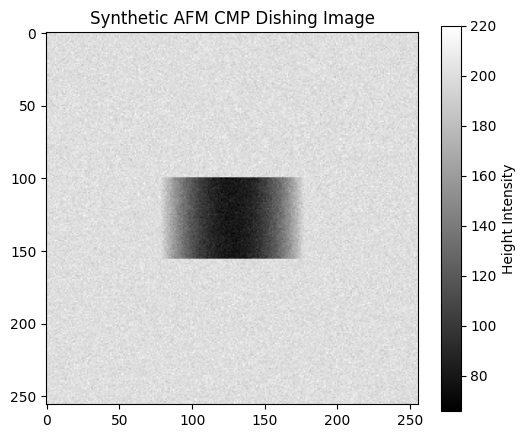

In [6]:
#1. 256*256 해상도의 가상 높이 맵 (AFM Height Map) 생성 (8비트 무부호 정수형)
height_map=np.ones((256,256), dtype=np.uint8)*200

#2. 중앙 Cu 배선 패임 (Dishing) 결함 생성 (어두운 포물선 영역)
x=np.linspace(-1,1,100)
dishing_profile=(1-x**2)*120 #패임 깊이 프로파일

for i in range(78, 178): #배선 폭 구간 (X축 78 ~ 177)
  depth=int(dishing_profile[i-78])
  #픽셀 값이 낮을수록 어두움(패임) -> 기준 높이 (200)에서 depth 차감
  height_map[100:156,i]=200-depth #기준 높이 지정

#3. 측정 노이즈 추가 및 8비트 이미지 범위(0~255) 클리핑
noise=np.random.normal(0,5,height_map.shape).astype(np.int16)
synthetic_afm=np.clip(height_map.astype(np.int16)+noise,0,255).astype(np.uint8)

# 시각화
plt.figure(figsize=(6,5))
plt.imshow(synthetic_afm, cmap='gray')
plt.colorbar(label='Height Intensity')
plt.title('Synthetic AFM CMP Dishing Image')
plt.show()

# **Step 2. OpenCV 이미지 필터링 & Otsu 자동 이진화/윤곽선 검출**

노이즈를 제거하고 어두운 결함 영역의 경계선(Contour)을 추출하는 컴퓨터 비전 전처리 단계이다.

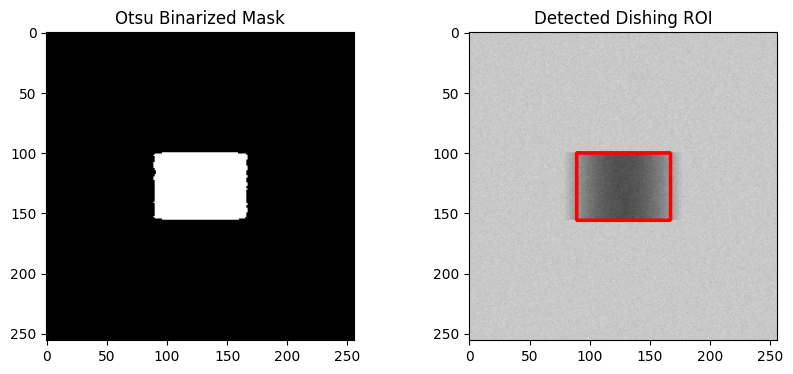

In [8]:
#1. 가우시안 블러로 노이즈 제거 (홀수 크기 커널 사용)
blurred=cv2.GaussianBlur(synthetic_afm,(5,5),0) # 5*5 가우시안 커널 크기

#2. Otsu 이진화 적용: 어두운 패임 영역을 흰색(255)으로 반전 추출
#반전 이진화 플래그(THRESH_BINARY_INV) + Otsu 자동 threshold 플래그 (THRESH_OTSU)
_, binary_mask=cv2.threshold(blurred,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

#3. 결함 경계 윤곽선 (Contour) 추출
contours,_=cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# 가장 외곽 윤곽선만 검색 (RETR_EXTERNAL)
# 윤곽선 단순화 체인 (CHAIN_APPROX_SIMPLE)

#4. 검출 결과 바운딩 박스 (Bounding Box) 시각화
result_img=cv2.cvtColor(synthetic_afm, cv2.COLOR_GRAY2BGR)
for cnt in contours:
  x,y,w,h=cv2.boundingRect(cnt)
  #rectangle(이미지, 좌상단 좌표, 우하단 좌표, 색상, 두께)
  cv2.rectangle(result_img, (x,y), (x+w,y+h), (255,0,0),2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(binary_mask, cmap='gray'); plt.title('Otsu Binarized Mask')
plt.subplot(1, 2, 2); plt.imshow(result_img); plt.title('Detected Dishing ROI')
plt.show()

# **Step3. 결함 정량화 수치 계산 & 2D 단면 프로파일 시각화**

검출된 결함의 면적 비율을 수학적으로 산출하고 단면 높이 변화를 2D 그래프로 추출하는 정량화 단계입니다.

=== CMP Defect Analysis Result ===
Total Pixels       : 65536
Defect Area Pixels : 4130
Defect Area Ratio  : 6.30%


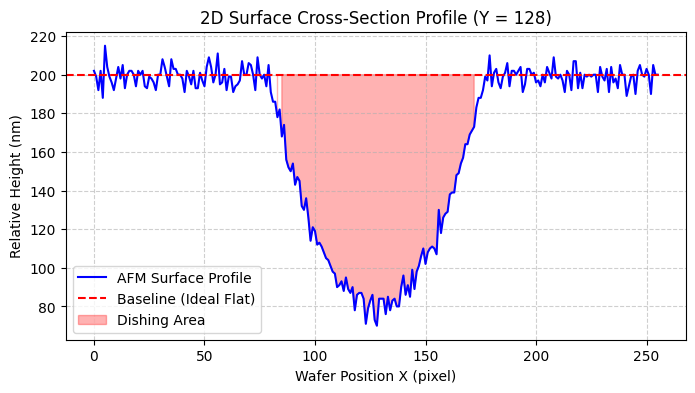

In [9]:
from matplotlib.lines import lineStyles
#1. 전체 이미지 피섹 수 및 결함 영역 픽셀 수 계산
total_pixels=synthetic_afm.shape[0]*synthetic_afm.shape[1]
defect_pixels=0

for cnt in contours:
  defect_pixels+=cv2.contourArea(cnt) #윤곽선 면적 계산 함수 입력

#2. Defect Area Ratoio (%) 공식 적용
defect_ratio=(defect_pixels/total_pixels)*100

print(f"=== CMP Defect Analysis Result ===")
print(f"Total Pixels       : {total_pixels}")
print(f"Defect Area Pixels : {defect_pixels:.0f}")
print(f"Defect Area Ratio  : {defect_ratio:.2f}%")

#3. Y=128 수평 위치의 단면 높이 프로파일 추출 (Numpy 2D Slicing)
profile_line=synthetic_afm[128, :]

#4. 2D Surface Cross-Section Profile 시각화
plt.figure(figsize=(8,4))
plt.plot(profile_line, 'b-', label='AFM Surface Profile')
plt.axhline(y=200, color='r', linestyle='--', label='Baseline (Ideal Flat)')

#패인 영역 (Dishing Area) 색 채우기
plt.fill_between(range(256),profile_line,200,where=(profile_line<180),color='red',alpha=0.3, label='Dishing Area')
plt.title('2D Surface Cross-Section Profile (Y = 128)')
plt.xlabel('Wafer Position X (pixel)'); plt.ylabel('Relative Height (nm)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()